In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
data = yf.download(tickers=['SPY', 'ARCB'], interval='1wk', period="10y")["Close"]

[*********************100%***********************]  2 of 2 completed


In [3]:
rets = data[['SPY', 'ARCB']]
rets

Ticker,SPY,ARCB
Date,,
2016-08-22,185.090424,16.588839
2016-08-29,186.010422,17.359333
2016-09-05,181.674744,17.303637
2016-09-12,182.669479,17.535709
2016-09-19,184.912506,17.749222
...,...,...
2026-07-27,747.030029,144.221924
2026-08-03,773.260010,137.759995
2026-08-10,776.340027,142.880005


<Axes: xlabel='Date'>

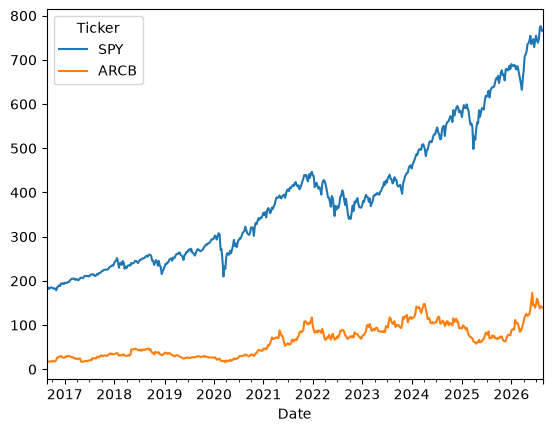

In [4]:
rets.plot()

<Axes: xlabel='Date'>

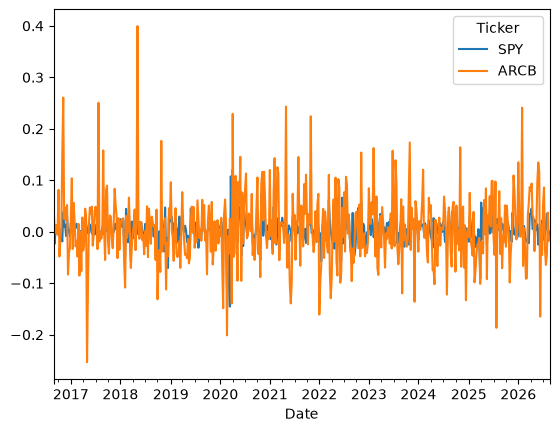

In [5]:
rets = rets.pct_change().dropna()
rets.plot()

In [6]:
compound_returns = (rets + 1).prod() - 1
(compound_returns * 100).round(2).astype('str') + '%'

Ticker
SPY      313.9%
ARCB    738.46%
dtype: str

In [7]:
rets.std()

Ticker
SPY     0.023703
ARCB    0.067790
dtype: float64

In [8]:
def annualize_rets(r, period_per_year=12):
    n_periods = r.shape[0]
    compound_growth = (1+r).prod()
    return compound_growth**(period_per_year/n_periods) - 1

In [9]:
def annualize_vol(r, periods_per_year=12):
    return r.std() * (periods_per_year**0.5)

In [10]:
#Raw Sharpe Ratio
annualize_rets(rets) / annualize_vol(rets)

Ticker
SPY     0.404246
ARCB    0.213331
dtype: float64

In [11]:
wealth_index = (rets+1).cumprod()
start_date = wealth_index.index.min() - pd.DateOffset(months=1)
wealth_index = pd.concat([pd.Series([1], index=[start_date]), wealth_index])

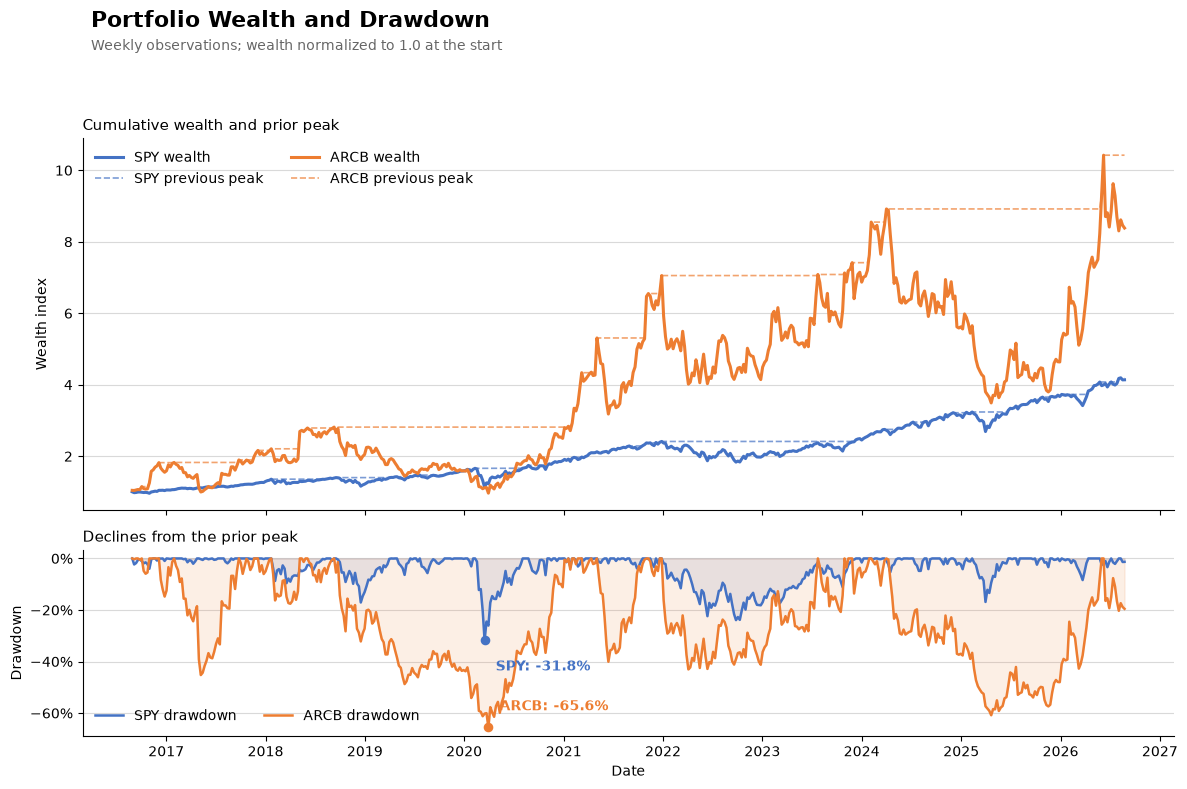

In [12]:
previous_peaks = wealth_index.cummax()
drawdowns = (wealth_index - previous_peaks) / previous_peaks

max_drawdown = drawdowns.min()
max_drawdown_rate = drawdowns.idxmin()

from matplotlib.ticker import PercentFormatter

# Plot wealth and drawdown on separate, aligned axes for easier comparison.
fig, (ax_wealth, ax_drawdown) = plt.subplots(
    2, 1, figsize=(12, 8), sharex=True,
    gridspec_kw={"height_ratios": [2, 1]},
)

colors = {"SPY": "#4472C4", "ARCB": "#ED7D31"}
for ticker, color in colors.items():
    ax_wealth.plot(wealth_index.index, wealth_index[ticker], color=color,
                   linewidth=2.2, label=f"{ticker} wealth")
    ax_wealth.plot(previous_peaks.index, previous_peaks[ticker], color=color,
                   linewidth=1.2, linestyle="--", alpha=0.7,
                   label=f"{ticker} previous peak")
    ax_drawdown.fill_between(drawdowns.index, drawdowns[ticker], 0,
                             color=color, alpha=0.12)
    ax_drawdown.plot(drawdowns.index, drawdowns[ticker], color=color,
                     linewidth=1.8, label=f"{ticker} drawdown")
    ax_drawdown.scatter(max_drawdown_rate[ticker], max_drawdown[ticker],
                        color=color, s=35, zorder=3)
    label_on_right = max_drawdown_rate[ticker] > drawdowns.index[int(len(drawdowns) * 0.82)]
    label_at_bottom = max_drawdown[ticker] <= drawdowns.min().min() + 0.10
    ax_drawdown.annotate(
        f"{ticker}: {max_drawdown[ticker]:.1%}",
        xy=(max_drawdown_rate[ticker], max_drawdown[ticker]),
        xytext=(-8 if label_on_right else 8, 10 if label_at_bottom else -14),
        textcoords="offset points",
        ha="right" if label_on_right else "left",
        va="bottom" if label_at_bottom else "top", color=color,
        fontsize=10, fontweight="bold",
    )

fig.suptitle("Portfolio Wealth and Drawdown", fontsize=16, fontweight="bold",
             x=0.08, ha="left")
fig.text(0.08, 0.93, "Weekly observations; wealth normalized to 1.0 at the start",
         fontsize=10, color="#666666")
ax_wealth.set_ylabel("Wealth index")
ax_drawdown.set_ylabel("Drawdown")
ax_drawdown.set_xlabel("Date")
ax_drawdown.yaxis.set_major_formatter(PercentFormatter(1.0))
ax_wealth.set_title("Cumulative wealth and prior peak", loc="left", fontsize=11)
ax_drawdown.set_title("Declines from the prior peak", loc="left", fontsize=11)
ax_wealth.legend(ncol=2, frameon=False, loc="upper left")
ax_drawdown.legend(ncol=2, frameon=False, loc="lower left")
for ax in (ax_wealth, ax_drawdown):
    ax.grid(axis="y", color="#D9D9D9", linewidth=0.8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_axisbelow(True)

fig.tight_layout(rect=[0, 0, 1, 0.91])
plt.show()
